In [22]:
from langgraph.graph import StateGraph,START,END
from langchain_ollama import ChatOllama
from typing import TypedDict,Annotated
import string
from pydantic import BaseModel,Field
import operator

In [7]:
model = ChatOllama(model='llama3.2:3b',temperature=0)

In [8]:
class EvaluationSchema(BaseModel):
    feedback:str = Field(description='Detailed Feedback For the Essay')
    score:int = Field(description='Score out of 10',ge=0,le=10)

In [9]:
structured_model = model.with_structured_output(EvaluationSchema)

In [13]:
essay = "The dawn of the twenty-first century has positioned India as a global technology powerhouse, but the emergence of Artificial Intelligence (AI) marks the beginning of an entirely new era. As AI fundamentally alters global industries, economies, and social structures, India stands at a critical crossroads. The country is uniquely positioned to transition from being the back office of the world to becoming a global hub for AI-driven innovation. In the age of AI, India’s journey is defined by immense economic opportunities, critical societal challenges, and a strategic imperative to ensure inclusive growth India's primary advantage in this technological revolution lies in its massive, tech-savvy population and demographic dividend. With the world's largest pool of young developers, engineers, and data scientists, India possesses the foundational human capital required to build, train, and deploy AI systems at scale. Furthermore, the country's rapid digital transformation over the past decade—driven by the India Stack, universal biometric identification (Aadhaar), and cheap mobile data—has created a hyper-connected society. This massive digital footprint generates vast oceans of diverse data, which serves as the essential raw material needed to train sophisticated machine learning models. \n  Financially and industrially, AI presents a multi-billion-dollar opportunity for India. The government’s AI for All strategy focuses on leveraging technology not just for commercial gain, but for large-scale social inclusion. In agriculture, AI-powered predictive models help farmers analyze weather patterns, optimize water usage, and maximize crop yields. In healthcare, AI diagnostics are bridging the severe doctor-to-patient deficit in rural areas, allowing localized clinics to detect early-stage cancers or cardiovascular anomalies through cloud-based tools. Similarly, AI-driven personalized learning platforms are revolutionizing education, adapting to the unique pace of students in remote schools where quality teaching resources are scarce. \n  However, the age of AI also introduces profound disruptions that India must navigate carefully. The most pressing concern is the vulnerability of the workforce. India’s massive Information Technology (IT) and Business Process Outsourcing (BPO) sectors, which employ millions, face immediate threats from automation. Generative AI can now write basic code, manage customer service queries, and generate content at a fraction of human cost. To prevent widespread unemployment, India must urgently execute a massive upskilling and reskilling campaign, shifting its workforce from routine execution to high-value AI oversight, prompt engineering, and system design. \n Beyond labor concerns, India faces substantial structural and ethical hurdles. The country must contend with deep digital divides; millions of citizens in rural or economically marginalized communities still lack reliable internet access, risking an exacerbation of existing social inequalities. Issues of data privacy, algorithmic bias, and deepfakes also pose serious risks to national security and democratic integrity. Because many foundational AI models are trained on Western datasets, they often lack cultural nuance and linguistic diversity, which can lead to biased outputs when applied to India's highly pluralistic society. \n To address these challenges, the Indian government and private sector are investing heavily in sovereign AI capabilities. Initiatives like the IndiaAI Mission aim to build domestic compting infrastructure, support localized startups, and develop AI models that understand and communicate in India's dozens of official regional languages. Establishing robust regulatory frameworks that protect data privacy while encouraging innovation remains a delicate but necessary balancing act. \n In conclusion, the age of AI is reshaping India’s destiny. It is an era filled with paradoxes—presenting the risk of labor displacement alongside the promise of unprecedented economic growth and social development. India’s success will ultimately depend on its ability to democratize AI, ensuring that the technology does not merely enrich a tech-elite but serves as a tool for mass empowerment. By blending technological ambition with ethical governance, India has the potential to lead the global Global South into a smarter, more equitable future."

In [15]:
prompt = f"Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \n {essay} "

In [16]:
output = structured_model.invoke(prompt)

In [19]:
print(f"feedback is : {output.feedback} \n score is : {output.score}")

feedback is : The essay provides a comprehensive analysis of the impact of Artificial Intelligence on India, highlighting both the opportunities and challenges it presents. The language is formal and professional, making it suitable for an academic or business audience. However, there are some areas that require improvement to enhance the overall quality of the essay. 
 score is : 8


In [23]:
class EvaluationState(TypedDict):
    essay : string
    language_feedback: string
    analysis_feedback: string
    clarity_feedback:string 
    overall_feedback:string
    individual_score:Annotated[list[int],operator.add]
    avg_score:float

In [25]:
def language_Evaluation(state:EvaluationState)->EvaluationState :
    prompt = f"Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \n {state['essay']} "
    evalutoion_result = structured_model.invoke(prompt)
    return {'language_feedback':evalutoion_result.feedback,'individual_score':[evalutoion_result.score]}

In [27]:
def Analysis_Evaluation(state:EvaluationState)->EvaluationState :
    prompt = f"Evaluate the depth of analysis of the following essay and provide a feedback and assign a score out of 10 \n {state['essay']} "
    evalutoion_result = structured_model.invoke(prompt)
    return {'analysis_feedback':evalutoion_result.feedback,'individual_score':[evalutoion_result.score]}

In [26]:
def Clarity_Evaluation(state:EvaluationState)->EvaluationState :
    prompt = f"Evaluate the clarity of the following essay and provide a feedback and assign a score out of 10 \n {state['essay']} "
    evalutoion_result = structured_model.invoke(prompt)
    return {'clarity_feedback':evalutoion_result.feedback,'individual_score':[evalutoion_result.score]}

In [28]:
def Final_Evaluation(state:EvaluationState)->EvaluationState :
    prompt = f"Evaluate the clarity ,depth analysis,language feedback of the essay and provide a overall feedback and avg score out of 10 \n language : {state['language_feedback']} \n depth analysis : {state['analysis_feedback']} \n clarity : {state['clarity_feedback']} "
    evalutoion_result = structured_model.invoke(prompt)
    return {'overall_feedback':evalutoion_result.feedback,'avg_score':[evalutoion_result.score]}

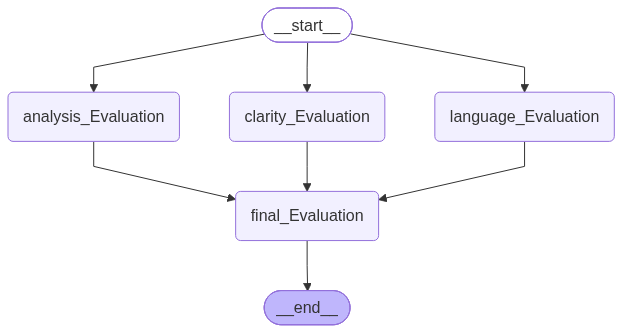

In [32]:
graph = StateGraph(EvaluationState)
graph.add_node('language_Evaluation',language_Evaluation)
graph.add_node('analysis_Evaluation',Analysis_Evaluation)
graph.add_node('clarity_Evaluation',Clarity_Evaluation)
graph.add_node('final_Evaluation',Final_Evaluation)
graph.add_edge(START,'language_Evaluation')
graph.add_edge(START,'analysis_Evaluation')
graph.add_edge(START,'clarity_Evaluation')
graph.add_edge('language_Evaluation','final_Evaluation')
graph.add_edge('analysis_Evaluation','final_Evaluation')
graph.add_edge('clarity_Evaluation','final_Evaluation')
graph.add_edge('final_Evaluation',END)

workflow = graph.compile()
workflow

In [40]:
final_state = workflow.invoke({'essay':'The dawn of the twenty-first century has positioned India as a global technology powerhouse, but the emergence of Artificial Intelligence (AI) marks the beginning of an entirely new era. As AI fundamentally alters global industries, economies, and social structures, India stands at a critical crossroads. The country is uniquely positioned to transition from being the IT hub of the world to becoming a global center for AI-driven innovation. In the age of AI, India’s journey is defined by immense economic opportunities, critical societal challenges, and a strategic imperative to ensure inclusive growth.\n\nIndias primary advantage in this technological revolution lies in its massive, tech-savvy population and demographic dividend. With the worlds largest pool of young developers, engineers, and data scientists, India possesses the foundational human capital required to build, train, and deploy AI systems at scale. Furthermore, the countrys rapid digital transformation over the past decade—driven by the India Stack, universal biometric identification, and highly accessible mobile data—has created a hyper-connected society. This massive digital footprint generates vast oceans of diverse data, which serves as the essential raw material needed to train sophisticated machine learning models.\n\nFinancially and industrially, AI presents a multi-billion-dollar opportunity for India. The government’s National Strategy for Artificial Intelligence focuses on leveraging technology not just for commercial gain, but for large-scale social inclusion. In agriculture, AI-powered predictive models help farmers analyze weather patterns, optimize water usage, and maximize crop yields. In healthcare, AI diagnostics are bridging the severe doctor-to-patient deficit in rural areas, allowing localized clinics to detect early-stage diseases through cloud-based tools. Similarly, AI-driven personalized learning platforms are revolutionizing education, adapting to the unique pace of students in remote schools where quality teaching resources are scarce.\n\nHowever, the age of AI also introduces profound disruptions that India must navigate carefully. The most pressing concern is the vulnerability of the workforce. India’s massive Information Technology and Business Process Outsourcing sectors, which employ millions, face immediate threats from automation. Generative AI can now write basic code, manage customer service queries, and generate content at a fraction of human cost. To prevent widespread unemployment, India must urgently execute a massive upskilling and reskilling campaign, shifting its workforce from routine execution to high-value AI oversight, prompt engineering, and system design.\n\nBeyond labor concerns, India faces substantial structural and ethical hurdles. The country must contend with deep digital divides; millions of citizens in rural or economically marginalized communities still lack reliable internet access, risking an exacerbation of existing social inequalities. Issues of data privacy, algorithmic bias, and deepfakes also pose serious risks to national security and democratic integrity. Because many foundational AI models are trained on Western datasets, they often lack cultural nuance and linguistic diversity, which can lead to biased outputs when applied to Indias highly pluralistic society.\n\nTo address these challenges, the Indian government and private sector are investing heavily in sovereign AI capabilities. Initiatives like the IndiaAI Mission aim to build domestic computing infrastructure, support localized startups, and develop AI models that understand and communicate in Indias dozens of official regional languages. Establishing robust regulatory frameworks that protect data privacy while encouraging innovation remains a delicate but necessary balancing act.\n\nIn conclusion, the age of AI is reshaping India’s destiny. It is an era filled with paradoxes—presenting the risk of labor displacement alongside the promise of unprecedented economic growth and social development. India’s success will ultimately depend on its ability to democratize AI, ensuring that the technology does not merely enrich a tech-elite but serves as a tool for mass empowerment. By blending technological ambition with ethical governance, India has the potential to lead the global community into a smarter, more equitable future.'})

In [41]:
final_state

{'essay': 'The dawn of the twenty-first century has positioned India as a global technology powerhouse, but the emergence of Artificial Intelligence (AI) marks the beginning of an entirely new era. As AI fundamentally alters global industries, economies, and social structures, India stands at a critical crossroads. The country is uniquely positioned to transition from being the IT hub of the world to becoming a global center for AI-driven innovation. In the age of AI, India’s journey is defined by immense economic opportunities, critical societal challenges, and a strategic imperative to ensure inclusive growth.\n\nIndias primary advantage in this technological revolution lies in its massive, tech-savvy population and demographic dividend. With the worlds largest pool of young developers, engineers, and data scientists, India possesses the foundational human capital required to build, train, and deploy AI systems at scale. Furthermore, the countrys rapid digital transformation over the

bad essay test

In [42]:
output = workflow.invoke({'essay':"India and AI is like big topic today. AI is coming very fast like a train and India is a big country with too many peoples so everything is changing. Some peoples say AI is good and some peoples say AI is bad but it is just computer stuff doing things that human brain used to do before. Now computers can think but they don't have feelings like us.\n\nFirst point is about jobs in India. India has many call centers and computer guys who work all day. But now AI can talk like human so what will happen to these peoples? They will lose jobs and become poor because robot is doing the work for free or very cheap. This is very bad for economy because money will not come. But also some peoples say new jobs will come but nobody knows what jobs because they are not invented yet. It is very confusing for young students who are studying in college right now.\n\nSecond point is about farms and doctors. In India there are many villages where no good doctors are there. AI can look at your mobile phone and tell what sickness you have. This is good because you don't have to go to city. Also for farming AI can tell if rain will come or not. If rain does not come then crops will die. But many farmers don't even have smart phone so how they will use AI? This means only rich peoples get the benefit and poor peoples stay same or get worse.\n\nAlso there is problem of fake things on internet. People make fake videos of actors and politicians and put on WhatsApp. Everyone believes it because it looks real but it is fake. This is called deep fake and it creates a lot of fights between peoples. Government wants to stop it but they cannot stop the internet because it is too big and everywhere.\n\nIn conclusion AI is very powerful thing like a double knife that can cut both sides. India must be careful or AI will destroy everything. We need more computers but also we need to save human beings. Let us hope for the best in the future of AI and India because technology never stops for anyone."})

In [43]:
output

{'essay': "India and AI is like big topic today. AI is coming very fast like a train and India is a big country with too many peoples so everything is changing. Some peoples say AI is good and some peoples say AI is bad but it is just computer stuff doing things that human brain used to do before. Now computers can think but they don't have feelings like us.\n\nFirst point is about jobs in India. India has many call centers and computer guys who work all day. But now AI can talk like human so what will happen to these peoples? They will lose jobs and become poor because robot is doing the work for free or very cheap. This is very bad for economy because money will not come. But also some peoples say new jobs will come but nobody knows what jobs because they are not invented yet. It is very confusing for young students who are studying in college right now.\n\nSecond point is about farms and doctors. In India there are many villages where no good doctors are there. AI can look at your m